In [1]:
# Plot global mortality as a distribution, final 10 years, ensemble mean

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from utils.utils import get_scenario_config

In [8]:
def load_global_mortality_ensemble_members(model, scenario, config, n_samples):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Global_mortality_{n_samples}samples_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [4]:
def process_global_mortality_for_plotting(da):
    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last10 = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = da_last10.year[0].item()
    end_time = da_last10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_last10.mean(dim=("ensemble", "year"))
    return da_mean, start_time, end_time

In [5]:
def plot_two_scenario_pdf(da1, da2, model, scenario1, scenario2, start_year, end_year, SAVE_DIR):

    # Convert xarray to numpy
    data1 = da1.values
    data2 = da2.values

    # Plot using seaborn KDE
    sns.kdeplot(data1, fill=True, label=scenario1)  # fill=True gives a shaded area under the curve
    sns.kdeplot(data2, fill=True, label=scenario2)  # fill=True gives a shaded area under the curve

    plt.xlabel("Mortality (year$^{-1}$)")
    plt.ylabel(" ")
    plt.legend()
    plt.title(f"Global COPD Mortality due to surface ozone\n {model} {start_year}-{end_year}")

    plt.tight_layout()

    out_file = f"Global_mortality_{model}_{scenario1}_{scenario2}_{start_year}-{end_year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)

    return

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Years are the same


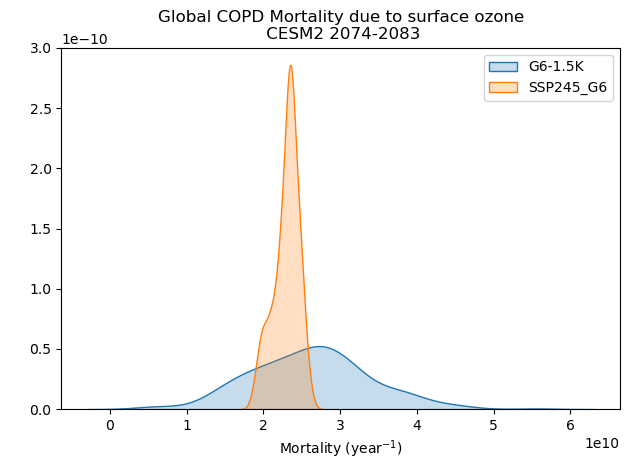

In [10]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "CESM2"
n_samples = 300

# Set up scenario 1 and 2 so that difference = s1 - s2
scenario1 = "G6-1.5K"
scenario2 = "SSP245_G6"

scenario_name = f"{scenario1}-{scenario2}"

config1 = get_scenario_config(model, scenario1)
config2 = get_scenario_config(model, scenario2)

da1 = load_global_mortality_ensemble_members(model, scenario1, config1, n_samples)
da2 = load_global_mortality_ensemble_members(model, scenario2, config2, n_samples)

da_mean1, first_year1, last_year1 = process_global_mortality_for_plotting(da1)
da_mean2, first_year2, last_year2 = process_global_mortality_for_plotting(da2)

if first_year1 == first_year2 and last_year1 == last_year2:
    print("Years are the same")

plot_two_scenario_pdf(da_mean1, da_mean2, model, scenario1, scenario2, first_year1, last_year1, SAVE_DIR)